# Data Generation

[ 0.    0.01  0.02 ...  9.98  9.99 10.  ]


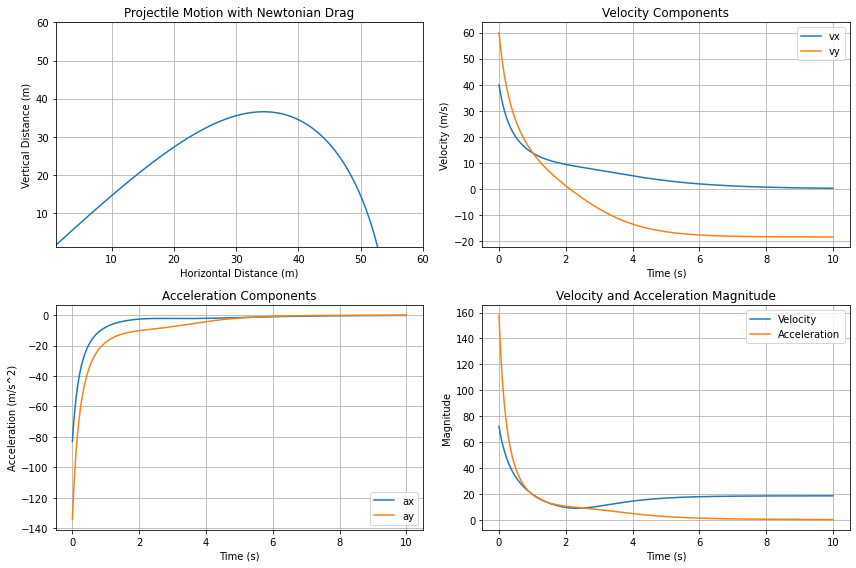

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # Acceleration due to gravity (m/s^2)
rho = 1.225  # Air density (kg/m^3)
Cd = 0.47  # Drag coefficient
A = 0.01  # Cross-sectional area (m^2)
m = 0.1  # Mass of the projectile (kg)

def runge_kutta_4th_order(f, x0, y0, h, n):
    x_vals = [x0]
    y_vals = [y0]
    for _ in range(n):
        k1 = h * f(x_vals[-1], y_vals[-1])
        k2 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k1 / 2)
        k3 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k2 / 2)
        k4 = h * f(x_vals[-1] + h, y_vals[-1] + k3)

        x_vals.append(x_vals[-1] + h)
        y_vals.append(y_vals[-1] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)
    return np.array(x_vals), np.array(y_vals)

def projectile_motion_with_drag(t, u):
    x, vx, y, vy = u
    g = 9.81  # Acceleration due to gravity (m/s^2)
    rho = 1.225  # Air density (kg/m^3)
    Cd = 0.47  # Drag coefficient
    A = 0.01  # Cross-sectional area (m^2)
    m = 0.1  # Mass of the projectile (kg)

    v = np.sqrt(vx**2 + vy**2)
    Fx = -0.5 * rho * Cd * A * v * vx
    Fy = -0.5 * rho * Cd * A * v * vy

    dxdt = vx
    dvxdt = (Fx / m)
    dydt = vy
    dvydt = (Fy / m) - g

    return np.array([dxdt, dvxdt, dydt, dvydt])

# Initial conditions
x0 = 0.0
y0 = 0.0
vx0 = 40.0
vy0 = 60.0

u0 = np.array([x0, vx0, y0, vy0])

# Time settings
t0 = 0.0
h = 0.01  # Step size
num_steps = 1000

# Solve the system of ODEs using Runge-Kutta 4th order
time_vals, state_vals = runge_kutta_4th_order(projectile_motion_with_drag, t0, u0, h, num_steps)
print(time_vals)
# Extract position, velocity, and acceleration values
x_vals = state_vals[:, 0]
vx_vals = state_vals[:, 1]
y_vals = state_vals[:, 2]
vy_vals = state_vals[:, 3]

# Calculate acceleration components ax and ay
ax_vals = (-0.5 * rho * Cd * A * vx_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m
ay_vals = (-0.5 * rho * Cd * A * vy_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m - g


# Concatenate the new columns to the original array
state_vals_2 = np.concatenate((state_vals, ax_vals[:, np.newaxis], ay_vals[:, np.newaxis]), axis=1)
#print(state_vals_2)

# Choose 100 random indices from both arrays
random_indices = np.random.choice(1000, size=3, replace=False)

# Use np.pick to select entries from the arrays using the random indices
time_vals20 = time_vals[random_indices]
state_vals20 = state_vals[random_indices]


# Calculate velocity magnitude v
v_vals = np.sqrt(vx_vals**2 + vy_vals**2)

# Calculate acceleration magnitude a
a_vals = np.sqrt(ax_vals**2 + ay_vals**2)

# Plot the trajectory, velocity, and acceleration
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals)
plt.title("Projectile Motion with Newtonian Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.xlim(1, 60)
plt.ylim(1, 60)
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(time_vals, vx_vals, label='vx')
plt.plot(time_vals, vy_vals, label='vy')
plt.title("Velocity Components")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(time_vals, state_vals_2[:, 4], label='ax')
plt.plot(time_vals, ay_vals, label='ay')
plt.title("Acceleration Components")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(time_vals, v_vals, label='Velocity')
plt.plot(time_vals, a_vals, label='Acceleration')
plt.title("Velocity and Acceleration Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# model creation

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#import the true solution , dtype=torch.float64
t_sol= torch.tensor(time_vals20, dtype=torch.float32).unsqueeze(1)
t_colocation = torch.linspace(0, 2*np.pi, 50).reshape(-1, 1)  # Separate colocation points
x_sol = torch.tensor(state_vals20[:,0], dtype=torch.float32).unsqueeze(1)
y_sol = torch.tensor(state_vals20[:,2], dtype=torch.float32).unsqueeze(1)
# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc_x = nn.Linear(64, 1)
        self.fc_y = nn.Linear(64, 1)

    def forward(self, x):
        dtype = self.fc1.weight.dtype
        x = torch.sigmoid(self.fc1(x.to(dtype)))
        x = torch.sigmoid(self.fc2(x.to(dtype)))
        x_output = self.fc_x(x)
        y_output = self.fc_y(x)
        return x_output, y_output

# vmapping


# Physicis informed loss

In [3]:
# Define the physics-informed loss
def physics_informed_loss(model, t_colocation):
    t_colocation.requires_grad = True  # Set requires_grad to True for the colocation points
    x_pred, y_pred = model(t_colocation)
    
    # Compute the second derivatives
    dx_dt = torch.autograd.grad(torch.sum(x_pred), t_colocation, create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(torch.sum(dx_dt), t_colocation, create_graph=True)[0]
    
    dy_dt = torch.autograd.grad(torch.sum(y_pred), t_colocation, create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(torch.sum(dy_dt), t_colocation, create_graph=True)[0]
    
        # physics parameters:
    g = 9.81  # Acceleration due to gravity (m/s^2)
    rho = 1.225  # Air density (kg/m^3)
    Cd = 0.47  # Drag coefficient
    A = 0.01  # Cross-sectional area (m^2)
    m = 0.1  # Mass of the projectile (kg)    
    v = torch.sqrt(dx_dt**2 + dy_dt**2)
    Fx = -0.5 * rho * Cd * A * v * dx_dt
    Fy = -0.5 * rho * Cd * A * v * dy_dt

    # Define the differential equation residuals
    residual_x = d2x_dt2 - Fx/m
    residual_y = d2y_dt2 - ((Fy/m)-g)
    
    # Calculate the mean squared residuals
    loss_x = torch.mean(residual_x ** 2)
    loss_y = torch.mean(residual_y ** 2)
        
    # Return the sum of losses
    return loss_x + loss_y

# Boundary loss

In [4]:
# Define the boundary loss
def boundary_loss(model):
    x_pred, y_pred = model(torch.tensor([0]).unsqueeze(1))
    
    # Define the boundary condition residuals
    residual_x = x_pred
    residual_y = y_pred
    
    # Calculate the mean squared residuals
    loss_x = torch.mean(residual_x ** 2)
    loss_y = torch.mean(residual_y ** 2)
    
    # Return the sum of losses
    return loss_x + loss_y

# Total Loss

In [5]:
# Define the total loss
def total_loss(model, t_sol):
    mse_loss = nn.MSELoss()
    x_pred, y_pred = model(t_sol)
    mse_sin = mse_loss(x_pred, x_sol)
    mse_cos = mse_loss(y_pred, y_sol)
    phys_loss = physics_informed_loss(model, t_colocation)
    bnd_loss = boundary_loss(model)
    return mse_sin + mse_cos + phys_loss + bnd_loss

# Training loop

In [6]:
# Initialize the model and optimizer
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    x_pred, y_pred = model(t_sol)
    loss = total_loss(model, t_sol)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')


Epoch [100/10000], Loss: 2287.328857421875
Epoch [200/10000], Loss: 1899.378662109375
Epoch [300/10000], Loss: 1452.28076171875
Epoch [400/10000], Loss: 1087.328857421875
Epoch [500/10000], Loss: 854.6748657226562
Epoch [600/10000], Loss: 706.5972290039062
Epoch [700/10000], Loss: 609.9369506835938
Epoch [800/10000], Loss: 536.1808471679688
Epoch [900/10000], Loss: 472.37005615234375
Epoch [1000/10000], Loss: 417.9335021972656
Epoch [1100/10000], Loss: 369.7098083496094
Epoch [1200/10000], Loss: 327.05999755859375
Epoch [1300/10000], Loss: 289.28302001953125
Epoch [1400/10000], Loss: 255.7642364501953
Epoch [1500/10000], Loss: 226.56455993652344
Epoch [1600/10000], Loss: 201.90219116210938
Epoch [1700/10000], Loss: 180.16061401367188
Epoch [1800/10000], Loss: 161.49612426757812
Epoch [1900/10000], Loss: 145.5348358154297
Epoch [2000/10000], Loss: 131.72886657714844
Epoch [2100/10000], Loss: 119.67353057861328
Epoch [2200/10000], Loss: 108.90509796142578
Epoch [2300/10000], Loss: 98.021

# Network prediction


In [7]:
# Generate 1000 random evaluation points between 0 and 10
t_eval_random = 10 * torch.rand(200, 1)
#print(t_eval_random.shape)
# Evaluate the trained model
x_pred, y_pred = model(t_eval_random)

# Plot

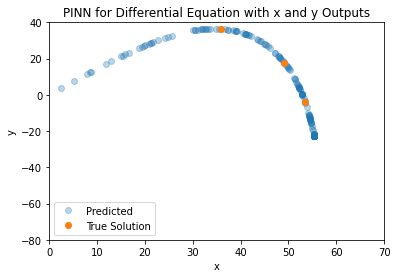

In [8]:
plt.plot( x_pred.detach().numpy(),y_pred.detach().numpy(),'o',alpha=0.3, label='Predicted')
plt.plot( x_sol.detach().numpy(),y_sol.detach().numpy(),'o', label='True Solution')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('PINN for Differential Equation with x and y Outputs')
# Set the y-axis limits 
plt.ylim(-80, 40)
plt.xlim(0,70)
plt.show()